### Testing differentiability for the tumor proliferation substep #1

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [2]:
class ProliferateTUCells(SubstepTransition):
    """
        Transition for the proliferation of tumor cells 
        Update the parameters of the tumor cells based on the proliferation nature 
        (symmetric or asymmetric). The parameters are updated as per the nature of
        proliferation. 

        Args:
            config (dict): initial state
            input_variables (dict): input variables
            output_variables (dict): output variables
            arguments (dict): arguments
            
        Returns:
            state (dict): updated state

        Parameters:
            proliferate_cell_index (torch.tensor): index of the cell to proliferate
            TUprolmax (torch.tensor): maximum capacity of proliferation
            TUpprol (torch.tensor): probability of proliferation
            Tum_proliferation_status (torch.tensor): proliferation status of the tumor cells
            Tum_engagement_status (torch.tensor): engagement status of the tumor cells
            TUintmax (torch.tensor): maximum number of interactions
            TUps (torch.tensor): probability of symmetric proliferation

        Steps:
            1. Feed the intial state to the transition function
            2. Decide the nature of the proliferation (symmetric or asymmetric) on the basis of TUps
                a. If random number is less than TUps, then symmetric proliferation
                b. Else asymmetric proliferation
            3. Read the variable values from the state and store them in the variables
            4. According to the nature of proliferation, we update the parameters of the tumor cells
            5. These tumors cell are of two types: one parent and a new daughter cell 
                (decided by the action substep)
                a. For the parent cell, we update the parameters as per the nature of proliferation
                    for both types of proliferation, we decrease the capacity of proliferation 
                    and interaction by 1, and rest remains same
                b. For the daughter cell, we update the parameters for symmetric proliferation, we
                    keep the capacity of proliferation and interaction same for asymmetric 
                    proliferation, we decrease the capacity of proliferation and interaction
                    by one, and rest remains same
            6. Return the updated state 
    
    """

    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)
        self.tumorcells_id = self.config['agents']['tumorcells']['id']

    def _get_symmetric_nature(self, TUps):
        random_number = torch.randn(1)
        if random_number < TUps:
            nature = "symmetric"
        else:
            nature = "asymmetric"
        return nature

    def forward(self, state):
        input_variables = self.input_variables

        # Define the parameters for the cells in state
        proliferate_cell_index = get_by_path(state, re.split("/", input_variables["proliferate_cell_index"]))
        TUprolmax = get_by_path(state, re.split("/", input_variables["TUprolmax"]))
        TUpprol = get_by_path(state, re.split("/", input_variables["TUpprol"]))
        Tum_proliferation_status = get_by_path(state, re.split("/", input_variables["Tum_proliferation_status"]))
        Tum_engagement_status = get_by_path(state, re.split("/", input_variables["Tum_engagement_status"]))
        TUintmax = get_by_path(state, re.split("/", input_variables["TUintmax"]))
        TUps = get_by_path(state, re.split("/", input_variables["TUps"]))

        # Decide the nature of the proliferation
        symmetric_nature = self._get_symmetric_nature(TUps)

        # Update the parameters based on the proliferation nature
        newcell = (proliferate_cell_index == self.tumorcells_id) | (proliferate_cell_index != -1)
        original = (proliferate_cell_index == -1)
        Tum_proliferation_status[newcell] = 1
        Tum_engagement_status[newcell] = 0
        TUpprol[newcell] = TUpprol[newcell]
        Tum_proliferation_status[original] = 1
        Tum_engagement_status[original] = 0
        TUpprol[original] = TUpprol[original]

        if symmetric_nature == 'symmetric':
            TUintmax[newcell] = TUintmax[newcell]
            TUprolmax[newcell] = TUprolmax[newcell]
            TUintmax[original] = TUintmax[original] - 1
            TUprolmax[original] = TUprolmax[original] - 1
        elif symmetric_nature == 'asymmetric':
            TUintmax[newcell] = TUintmax[newcell] - 1
            TUprolmax[newcell] = TUprolmax[newcell] - 1
            TUintmax[original] = TUintmax[original] - 1 
            TUprolmax[original] = TUprolmax[original] - 1
        
        return state

In [4]:
# Create an instance of ProliferateTUCells
config = {
    'agents': {
         'tumorcells': {
                'id': 1,
                'proliferate_cell_index': 1,
                'TUprolmax': torch.tensor([10]),
                'TUpprol': torch.tensor([0.5055]),
                'Tum_proliferation_status': torch.tensor([1]),
                'Tum_engagement_status': torch.tensor([0]),
                'TUintmax': torch.tensor([2]),
                'TUps': torch.tensor([0.7], requires_grad=True)
        }
    } 
}
input_variables = {
    'proliferate_cell_index': 'agents/tumorcells/proliferate_cell_index',
    'TUprolmax': 'agents/tumorcells/TUprolmax',
    'TUpprol': 'agents/tumorcells/TUpprol',
    'Tum_proliferation_status': 'agents/tumorcells/Tum_proliferation_status',
    'Tum_engagement_status': 'agents/tumorcells/Tum_engagement_status',
    'TUintmax': 'agents/tumorcells/TUintmax',
    'TUps': 'agents/tumorcells/TUps'
}
output_variables = {} 
arguments = {
    'learnable': {}, 
    'fixed': {}       
}

proliferate_cells = ProliferateTUCells(config, input_variables, output_variables, arguments)

# Forward pass
output_state = proliferate_cells(config)

In [5]:
output_state

{'agents': {'tumorcells': {'id': 1,
   'proliferate_cell_index': 1,
   'TUprolmax': tensor([9]),
   'TUpprol': tensor([0.5055]),
   'Tum_proliferation_status': tensor([1]),
   'Tum_engagement_status': tensor([0]),
   'TUintmax': tensor([1]),
   'TUps': tensor([0.7000], requires_grad=True)}}}

In [6]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [7]:
print(output_state_sum)
loss = output_state_sum

tensor(12.2055, grad_fn=<AddBackward0>)


In [8]:
loss.requires_grad

True

In [9]:
loss.backward()

In [10]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [11]:
input_state_sum.requires_grad

True

In [12]:
import torch
import torch.optim as optim

In [13]:
TUps = config['agents']['tumorcells']['TUps']
optimizer = optim.SGD([TUps], lr=0.01)

In [14]:
grad_values = []

for epoch in range(10):
    # Forward pass
    output_state = proliferate_cells(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of TUps:', TUps.grad)
    # Store TUps.grad values in the list
    grad_values.append(TUps.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated TUps values
    print('Updated TUps:', TUps)
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

Gradient of TUps: tensor([2.])
Updated TUps: tensor([0.6800], requires_grad=True)
Loss: 10.205499649047852
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6700], requires_grad=True)
Loss: 8.185500144958496
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6600], requires_grad=True)
Loss: 6.17549991607666
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6500], requires_grad=True)
Loss: 4.165499687194824
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6400], requires_grad=True)
Loss: 2.1554999351501465
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6300], requires_grad=True)
Loss: 0.14549988508224487
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6200], requires_grad=True)
Loss: -1.864499807357788
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6100], requires_grad=True)
Loss: -3.874500036239624
Gradient of TUps: tensor([1.])
Updated TUps: tensor([0.6000], requires_grad=True)
Loss: -5.884500026702881
Gradient of TUps: tensor([1.])
Updated T

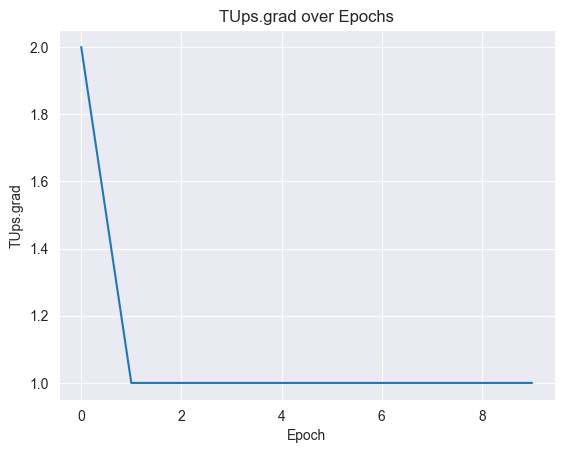

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('TUps.grad')
plt.title('TUps.grad over Epochs')
plt.show()